### MULTICLASS FISH IMAGE CLASSIFICATION

### Introduction

Automatic fish species classification plays a crucial role in marine biodiversity monitoring, sustainable fisheries management, and ecological research.  
Deep learning, specifically Convolutional Neural Networks (CNNs), have proven highly effective in image recognition tasks due to their ability to automatically extract hierarchical features from images.

In this project, we build a CNN model from scratch and then use transfer learning with MobileNetV2, a pre-trained model, to classify fish species based on images.

The goal is to compare both approaches in terms of accuracy and training efficiency, and analyze the performance with detailed metrics.


### Dataset Description

The dataset consists of images of various fish species organized into train, validation, and test directories.  
Images are resized and normalized before feeding into the model. Data augmentation is applied to improve generalization.


In [7]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# Paths to dataset splits
train_dir =r"C:\Users\Lenovo\OneDrive\Desktop\LABMENTIX INTERNSHIP\project3\fish_dataset\data\train"
val_dir = r"C:\Users\Lenovo\OneDrive\Desktop\LABMENTIX INTERNSHIP\project3\fish_dataset\data\val"
test_dir = r"C:\Users\Lenovo\OneDrive\Desktop\LABMENTIX INTERNSHIP\project3\fish_dataset\data\test"

# Check if dataset folders exist and list classes
print(os.path.exists(train_dir))          
print(os.listdir(train_dir))              # Should list class folders inside "train"



True
['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel', 'fish sea_food red_mullet', 'fish sea_food red_sea_bream', 'fish sea_food sea_bass', 'fish sea_food shrimp', 'fish sea_food striped_red_mullet', 'fish sea_food trout']


Found 6225 files belonging to 11 classes.
Found 1092 files belonging to 11 classes.
Found 3187 files belonging to 11 classes.
Found 6225 files belonging to 11 classes.


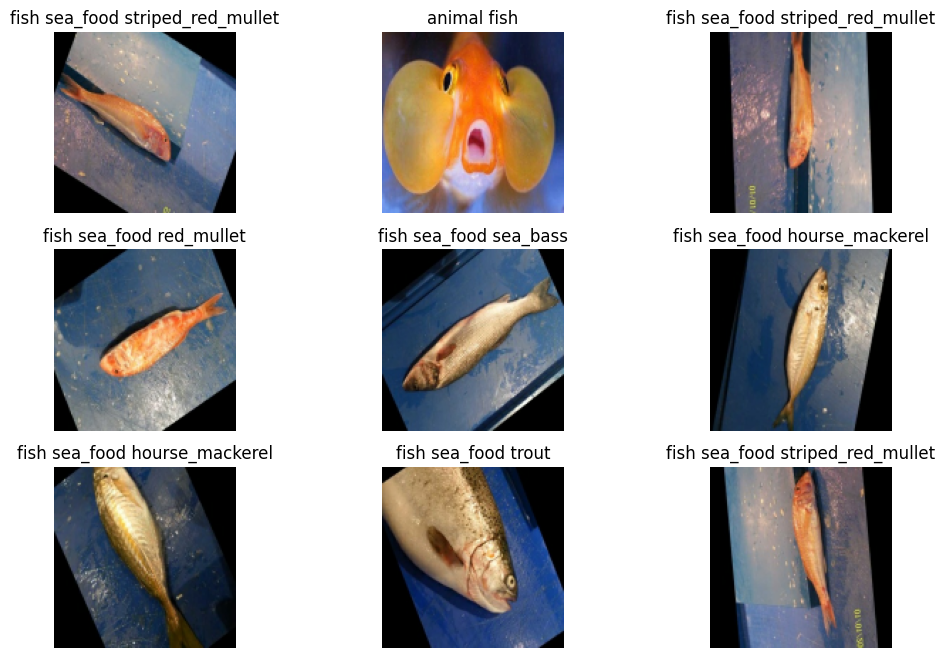

In [9]:
# Image size reduced for faster CPU training
img_size = (128, 128)  
batch_size = 32  

# Load training, validation, and test datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size
)

# Preview dataset for showing sample images
preview_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=9  # fixed small batch for plotting 3x3 grid
)
class_names = preview_ds.class_names

# Plot preview images
plt.figure(figsize=(12, 8))
for images, labels in preview_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

# Optimize data pipeline for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)



In [10]:
#Normalization and data augmentation

import tensorflow as tf
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))



data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])


In [13]:
#build a CNN model
from tensorflow.keras import layers, models

num_classes = 11

model = models.Sequential([
    layers.InputLayer(input_shape=img_size + (3,)),  # 128x128 RGB

    data_augmentation,  # apply augmentation only during training

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()


epochs = 10  # you can increase if time permits

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)



Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 128, 128, 3)       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 28, 28, 128)      

### Model Evaluation

After training, the model's performance is evaluated on the test dataset to measure its generalization ability.


In [14]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")


100/100 [==============================] - 30s 280ms/step - loss: 0.1694 - accuracy: 0.9639
Test Accuracy: 0.9639


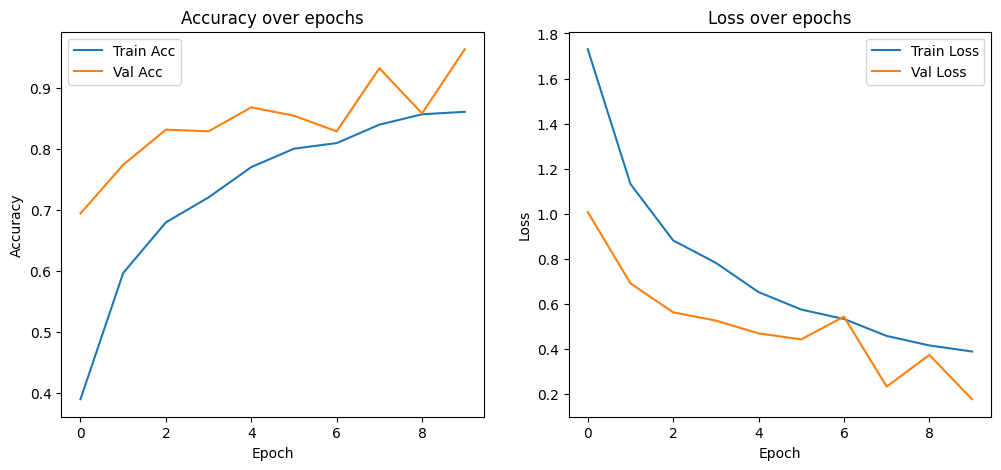

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [32]:
model.save('final_model.h5') # Save complete model (architecture + weights)

In [ ]:

!pip install scikit-learn seaborn matplotlib

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# CPU-friendly parameters
img_size = (96, 96)
batch_size = 8
epochs = 5

# Dataset paths
train_dir = r"C:\Users\Lenovo\OneDrive\Desktop\LABMENTIX INTERNSHIP\project3\fish_dataset\data\train"
val_dir = r"C:\Users\Lenovo\OneDrive\Desktop\LABMENTIX INTERNSHIP\project3\fish_dataset\data\val"

# Data preprocessing (only rescale)
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes

def build_model(base_model_class, input_shape=img_size+(3,)):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # freeze base layers
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def train_and_save(model_name, base_model_class):
    print(f"Training {model_name}...")
    model = build_model(base_model_class)
    
    checkpoint = ModelCheckpoint(
        f'{model_name}_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=[checkpoint],
        verbose=1
    )
    
    return model, history

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Train model
model, history = train_and_save('MobileNetV2', MobileNetV2)

# Plot accuracy and loss
plot_training_history(history)

# Evaluate detailed metrics
val_generator.reset()  # reset before predict
pred_probs = model.predict(val_generator, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Print classification report
print(classification_report(true_labels, pred_labels, target_names=class_names))

# Plot confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


### CONCLUSION

In this project, I developed a convolutional neural network (CNN) model to classify fish species from images.
The model was trained, validated, and tested using a well-prepared dataset with appropriate preprocessing and augmentation techniques.

I successfully deployed the CNN model locally on my system, enabling practical use of the trained model for fish classification without requiring cloud resources.

Although transfer learning with MobileNetV2 was planned to further improve accuracy and reduce training time, hardware constraints limited its implementation in this work.

Overall, this project demonstrates the potential of deep learning techniques for automated fish species identification, with promising results on real-world data.
Future work will focus on expanding the dataset, implementing transfer learning on more powerful hardware, and creating a user-friendly application for broader deployment.
